# Image Embedding-Based Grape Leaf Disease Classification

Author: **Marcin Sikorski**<br>
Date: June, 2026

This notebook explores grape leaf disease classification using deep image embeddings extracted from pre-trained EfficientNetB0 network. This CNN will work as a feature extractor, while classical machine learning models perform the final classification task.

Workflow for this image classification:
1. Use a pretrained EfficientNetB0 as a baseline feature extractor.
2. Convert each image into a dense embedding vector.
3. Feed the embeddings into a classical machine learning model from scikit-learn.
4. Train and evaluate the classifier.

In [ ]:
# mount G-Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**Notebook Content:**
1. Importing and Reviewing Dataset
2. Image Embedding Vectors
3. Predictions and Evaluation
    1. K-Nearest Neighbors
    2. Histogram-based Gradient Boosting
    3. Multilayer Perceptron
    4. Linear Discriminant Analysis
    5. Confusion Matrices
    6. Multiclass ROC Curves
4. Conclusions

### 1. Importing and Reviewing Dataset

The dataset is distributed as a ZIP archive. To improve data loading performance during training and feature extraction, we will temporarily extract it to local SSD storage.

In [ ]:
# copy zip file from G-Drive → fast local SSD
!cp /content/drive/MyDrive/grape-leaf-diseases.zip /content/

# unzip quietly
!unzip -q /content/grape-leaf-diseases.zip -d /content/

print('Dataset ready in /content')

Dataset ready in /content


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os

# train paths
train_image_path = '/content/grape/images/train/'
train_label_path = '/content/grape/labels/train/'

train_data = []
for file_name in os.listdir(train_image_path):

  # get corresponding label in TXT file
  label_name = file_name.replace('.jpg', '.txt')

  # open TXT file and read label as integer
  with open(train_label_path + label_name) as f:
    label = int(f.read().strip()[0])

  train_data.append({
      'image_name': file_name,
      'image_label': label,
      })

# train data
df_train = pd.DataFrame(train_data, columns=['image_name', 'image_label'])
df_train.head()

,image_name,image_label
0,pv_GRES_image (570).jpg,1
1,pv_GRES_image (1030).jpg,1
2,pv_GRLB_image (927).jpg,3
3,pv_GRES_image (684).jpg,1
4,pv_GRBR_image (603).jpg,0


In [ ]:
# validation paths
val_image_path = '/content/grape/images/val/'
val_label_path = '/content/grape/labels/val/'

val_data = []
for file_name in os.listdir(val_image_path):

  # get corresponding label in TXT file
  label_name = file_name.replace('.jpg', '.txt')

  # open TXT file and read label as integer
  with open(val_label_path + label_name) as f:
    label = int(f.read().strip()[0])

  val_data.append({
      'image_name': file_name,
      'image_label': label,
      })

# validation data
df_val = pd.DataFrame(val_data, columns=['image_name', 'image_label'])
df_val.head()

,image_name,image_label
0,pv_GRES_image (884).jpg,1
1,pv_GRES_image (670).jpg,1
2,pv_GRLB_image (128).jpg,3
3,pv_GRES_image (485).jpg,1
4,pv_GRHE_image (52).jpg,2


In [ ]:
# check data types
df_train.dtypes, df_val.dtypes

(image_name     object
 image_label     int64
 dtype: object,
 image_name     object
 image_label     int64
 dtype: object)

In [ ]:
# image count
print('Train images:', len(df_train))
print('Val images:  ', len(df_val))

Train images: 3358
Val images:   837


### 2. Image Embedding Vectors

To generate image embeddings, we will use EfficientNetB0 as the embedding model.

In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.models import Model

# backbone model
base_model = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3),
    pooling='avg',
    classifier_activation='softmax',
    )

# embedding model
embedding_model = Model(
    inputs=base_model.input,
    outputs=base_model.output,
    )

print('Embedding size:', embedding_model.output_shape)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Embedding size: (None, 1280)


In [ ]:
# executes ~8-14 min
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.efficientnet import preprocess_input

IMG_SIZE = 224
BATCH_SIZE = 32

# new embeddings and labels
X = []
y = []

# collect image paths + labels
datasets = [
    (train_image_path, train_label_path),
    (val_image_path, val_label_path),
    ]

# loop through dataset
for image_dir, label_dir in datasets:
  image_files = os.listdir(image_dir)

  for file in image_files:
    # skip non-image files
    #if not file.lower().endswith(('.jpg', '.jpeg', '.png')):
    #  continue

    img_path = os.path.join(image_dir, file)

    # convert image filename -> label filename
    label_file = os.path.splitext(file)[0] + '.txt'
    label_path = os.path.join(label_dir, label_file)

    try:
      # load image
      img = image.load_img(
          img_path,
          target_size=(IMG_SIZE, IMG_SIZE),
          )

      img_array = image.img_to_array(img)
      img_array = np.expand_dims(img_array, axis=0)
      img_array = preprocess_input(img_array)

      # generate embedding
      embedding = embedding_model.predict(
          img_array,
          verbose=0,
          batch_size=BATCH_SIZE,
          )

      X.append(embedding.flatten())

      # read only label (as int)
      with open(label_path, 'r') as f:
        label = int(f.readline().split()[0])

        y.append(label)

    except Exception as e:
      print('Error:', file, e)

In [ ]:
# convert to NumPy arrays
X = np.array(X, dtype=np.float32)
y = np.array(y)#.astype(int)

# embeddings and labels
print('Embeddings shape:', X.shape)
print('Labels shape:'    , y.shape)

Embeddings shape: (4195, 1280)
Labels shape: (4195,)


To diagnose embedding correctness, we can visualize diseases as clusters using UMAP.

In [ ]:
import umap

# vector norm (avoid NaNs)
norms = np.linalg.norm(X, axis=1, keepdims=True)
norms = np.maximum(norms, 1e-12)

# UMAP embeddings
umap_embeddings = X / norms

# compress embeddings into 2D coordinates
reducer = umap.UMAP(
    n_neighbors=30,
    min_dist=0.05,
    metric='cosine',
    random_state=42,
    )

X_2d = reducer.fit_transform(umap_embeddings)

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


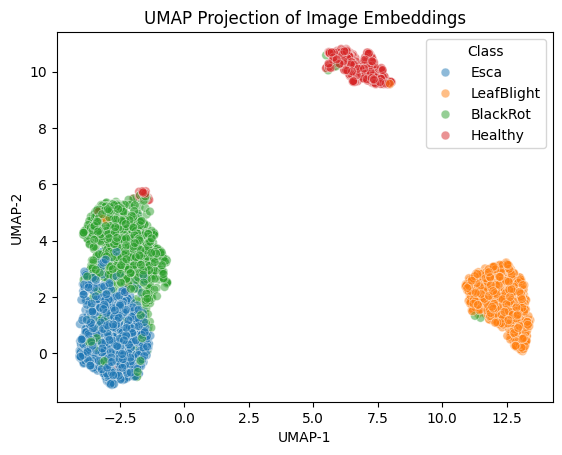

In [ ]:
from seaborn import scatterplot

# class labelling
class_names = ['BlackRot', 'Esca', 'Healthy', 'LeafBlight']

df_umap = pd.DataFrame({
    'x': X_2d[:, 0],
    'y': X_2d[:, 1],
    'class': [class_names[i] for i in y],
    })

# UMAP plot
scatterplot(
    data=df_umap,
    x='x',
    y='y',
    hue='class',
    alpha=0.5,
    s=40,
    )

plt.title('UMAP Projection of Image Embeddings')
plt.xlabel('UMAP-1')
plt.ylabel('UMAP-2')
plt.legend(title='Class')

plt.show()

This UMAP plot shows local neighborhood structure is preserved much better than global geometry. It shows clear disease-specific structure. This visualization is quite informative and a few things stand out immediately:
* The embeddings are learning meaningful structure. Poor embeddings would generate a big mixed cloud or blob with all four classes overlapping. Instead, we have clearly separated regions.
* The **Healthy** class is the easiest. It shows almost no contamination from other classes and is well separated. This suggests Healthy leaves have visual characteristics that are consistently different from diseased leaves.
* The **LeafBlight** class is also highly separable. Again, this class has distinctive visual patterns that the embedding network captures well.
* **Esca** and **BlackRot** are the problematic pair. This two overlap, meaning that they share similarities and will generate the most confusion.

Overall, the embedding quality looks very good and meaningful for classification. Possibly the classes are highly linearly separable in the embedding space.

Other quantitative checks to determine class separation (how separated the classes truly are in embedding space), we can compute metrics in the original embedding dimensions, such as:
* silhouette score,
* k-NN classification accuracy on embeddings,
* Fisher discriminant ratio.


In [ ]:
from sklearn.metrics import silhouette_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score

# 1. silhouette score
sil_score = silhouette_score(X, y)

# 2. k-NN classification accuracy
knn = KNeighborsClassifier(n_neighbors=5)

knn_scores = cross_val_score(
    knn,
    X,
    y,
    cv=5,
    scoring='accuracy',
    )

# 3. Fisher discriminant ratio
def fisher_ratio_matrix(embeddings, labels):
    classes = np.unique(labels)
    n_features = embeddings.shape[1]

    overall_mean = np.mean(embeddings, axis=0)

    # new matrices
    S_w = np.zeros((n_features, n_features))
    S_b = np.zeros((n_features, n_features))

    # ratio for each class
    for cls in classes:
        X_c = embeddings[labels == cls]
        mean_c = np.mean(X_c, axis=0)

        centered = X_c - mean_c
        S_w += centered.T @ centered        # within-class scatter

        diff = (mean_c - overall_mean).reshape(-1, 1)
        S_b += len(X_c) * (diff @ diff.T)   # between-class scatter

    return np.trace(S_b) / np.trace(S_w)

fdr = fisher_ratio_matrix(X, y)

print(f'Silhouette Score: {sil_score:.4f}')
print(f'k-NN Accuracy:     {knn_scores.mean():.4f}')
print(f'Fisher Ratio:     {fdr:.4f}')

Silhouette Score: 0.1270
k-NN Accuracy:     0.9664
Fisher Ratio:     0.3628


These scores display pretty coherent conclusions if we consider what each metric measures.

| Metric        | What it measures                                       |
| ------------- | ------------------------------------------------------ |
| Silhouette    | Relative cluster compactness and separation            |
| k-NN Accuracy | Local neighborhood purity                              |
| FDR           | Global ratio of between-class to within-class variance |

The UMAP plot suggests:
* **Healthy** forms a tight isolated cluster,
* **LeafBlight** forms a tight isolated cluster,
* **Esca** and **BlackRot** occupy overlapping regions in the UMAP projection.

This situation often produces:
* high classification accuracy,
* low-to-moderate silhouette,
* low global FDR.

Why? The most separated classes are very easy, but the overall within-class variance remains large because Esca and BlackRot occupy a broad shared region.

The relatively low Fisher discriminant ratio (FDR) indicates that within-class variance is large relative to between-class variance. It means the within-class spread is larger than the between-class separation. The plot and FDR may not be contradictory. This UMAP shows distinct clusters, but UMAP emphasizes local structure and classes can form visually separate islands while still having large internal variance in the original space. The low silhouette score indicates limited cluster compactness and separation according to the silhouette criterion.

The k-NN result is particularly informative. Its high accuracy means that in the original embedding space, samples are usually surrounded by same-class samples. That is strong evidence the embedding is useful. This score is a stronger indicator of embedding quality than the silhouette score alone.

Overall, the results suggest that the embedding space contains strong local class structure and supports accurate classification, but the classes do not form compact, globally well-separated spherical clusters.

### 3. Predictions and Evaluation

With the generated embedding vectors, we can make predictions and perform evaluations using classification metrics, confusion matrices, and related methods. For image classification, we will implement these models:
* k-nearest neighbors,
* histogram-based gradient boosting,
* multilayer perceptron (MLP),
* linear discriminant analysis.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    f1_score,
    roc_auc_score,
    classification_report,
    )

# partion data
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    train_size=0.8,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

# class labelling
class_names = ['BlackRot', 'Esca', 'Healthy', 'LeafBlight']

#### 3.1. K-Nearest Neighbors

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

# scaling features is highly recommended for k-NN
knn = make_pipeline(
    StandardScaler(),
    KNeighborsClassifier(n_neighbors=3, metric='cosine'),
    )

knn.fit(X_train, y_train)

# k-NN predictions
knn_pred = knn.predict(X_test)

print(classification_report(
    y_test,
    knn_pred,
    target_names=class_names,
    )
)

print('Misclassified images: {} out of {}'.format((y_test != knn_pred).sum(), len(y_test)))

              precision    recall  f1-score   support

    BlackRot       0.93      0.96      0.94       249
        Esca       0.97      0.95      0.96       277
     Healthy       0.96      0.97      0.96        98
  LeafBlight       1.00      1.00      1.00       215

    accuracy                           0.97       839
   macro avg       0.97      0.97      0.97       839
weighted avg       0.97      0.97      0.97       839

Misclassified images: 29 out of 839


In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_validate

# K-fold cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# multiple scoring metrics
scoring = {
    'roc_auc': 'roc_auc_ovr',
    'f1': 'f1_weighted',
    }

knn_scores = cross_validate(
    knn,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1,
    error_score='raise',
    )

print(f'Mean ROC-AUC:  {knn_scores['test_roc_auc'].mean():.4f}')
print(f'Mean F1 Score: {knn_scores['test_f1'].mean():.4f}')

Mean ROC-AUC:  0.9908
Mean F1 Score: 0.9586


#### 3.2. Histogram-based Gradient Boosting

In [ ]:
from sklearn.ensemble import HistGradientBoostingClassifier

# scaling data is not necessary
hgb = HistGradientBoostingClassifier(max_iter=300, random_state=42)

hgb.fit(X_train, y_train)

# HGB predictions
hgb_pred = hgb.predict(X_test)

print(classification_report(
    y_test,
    hgb_pred,
    target_names=class_names,
    )
)

print('Misclassified images: {} out of {}'.format((y_test != hgb_pred).sum(), len(y_test)))

              precision    recall  f1-score   support

    BlackRot       0.98      0.96      0.97       249
        Esca       0.97      0.99      0.98       277
     Healthy       0.98      0.98      0.98        98
  LeafBlight       1.00      1.00      1.00       215

    accuracy                           0.98       839
   macro avg       0.98      0.98      0.98       839
weighted avg       0.98      0.98      0.98       839

Misclassified images: 17 out of 839


In [ ]:
# HGB cross-validation scoring
hgb_scores = cross_validate(
    hgb,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1,
    error_score='raise',
    )

print(f'Mean ROC-AUC:  {hgb_scores['test_roc_auc'].mean():.4f}')
print(f'Mean F1 Score: {hgb_scores['test_f1'].mean():.4f}')

Mean ROC-AUC:  0.9989
Mean F1 Score: 0.9717


#### 3.3. Multilayer Perceptron

In [ ]:
from sklearn.neural_network import MLPClassifier

# scaling data is not necessary
mlp = MLPClassifier(
    hidden_layer_sizes=(256, 128),
    activation='relu',
    max_iter=1_000,
    random_state=42,
    )

mlp.fit(X_train, y_train)

# MLP predictions
mlp_pred = mlp.predict(X_test)

print(classification_report(
    y_test,
    mlp_pred,
    target_names=class_names,
    )
)

print('Misclassified images: {} out of {}'.format((y_test != mlp_pred).sum(), len(y_test)))

              precision    recall  f1-score   support

    BlackRot       0.99      0.99      0.99       249
        Esca       0.99      0.99      0.99       277
     Healthy       0.99      0.99      0.99        98
  LeafBlight       1.00      1.00      1.00       215

    accuracy                           0.99       839
   macro avg       0.99      0.99      0.99       839
weighted avg       0.99      0.99      0.99       839

Misclassified images: 6 out of 839


In [ ]:
# MLP cross-validation scoring
mlp_scores = cross_validate(
    mlp,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1,
    error_score='raise',
    )

print(f'Mean ROC-AUC:  {mlp_scores['test_roc_auc'].mean():.4f}')
print(f'Mean F1 Score: {mlp_scores['test_f1'].mean():.4f}')

Mean ROC-AUC:  0.9996
Mean F1 Score: 0.9863


#### 3.4. Linear Discriminant Analysis

In [ ]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# scaling data is not necessary
lda = LinearDiscriminantAnalysis()

lda.fit(X_train, y_train)

# LDA predictions
lda_pred = lda.predict(X_test)

print(classification_report(
    y_test,
    lda_pred,
    target_names=class_names,
    )
)

print('Misclassified images: {} out of {}'.format((y_test != lda_pred).sum(), len(y_test)))

              precision    recall  f1-score   support

    BlackRot       1.00      0.97      0.98       249
        Esca       0.98      1.00      0.99       277
     Healthy       0.98      0.98      0.98        98
  LeafBlight       1.00      1.00      1.00       215

    accuracy                           0.99       839
   macro avg       0.99      0.99      0.99       839
weighted avg       0.99      0.99      0.99       839

Misclassified images: 10 out of 839


In [ ]:
# LDA cross-validation scoring
lda_scores = cross_validate(
    lda,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1,
    error_score='raise',
    )

print(f'Mean ROC-AUC:  {lda_scores['test_roc_auc'].mean():.4f}')
print(f'Mean F1 Score: {lda_scores['test_f1'].mean():.4f}')

Mean ROC-AUC:  0.9942
Mean F1 Score: 0.9752


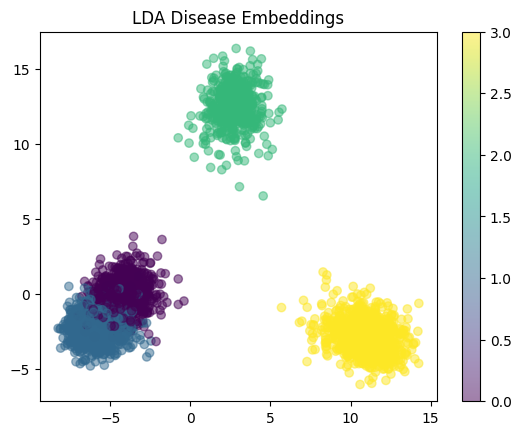

In [ ]:
# train new model to visualize embeddings
lda_mod = LinearDiscriminantAnalysis(n_components=2)

X_lda = lda_mod.fit_transform(X, y)

#plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    X_lda[:, 0],
    X_lda[:, 1],
    c=y,
    #cmap='tab10',
    alpha=0.5,
    )

plt.colorbar(scatter)
plt.title('LDA Disease Embeddings')
plt.show()

Unlike UMAP, LDA is explicitly linear and supervised. It finds projections that maximize the ratio of between-class variance to within-class variance. This plot reflects how well the classes can be separated by a linear projection of the embeddings. The classes appear well separated in the LDA projection.

LDA shows very clearly that there is a linear projection where classes separate well. Combined with high k-NN accuracy, low silhouette and clear LDA, the embedding space likely has strong linear structure and is close to linearly separable with strong local structure, but not composed of compact spherical clusters.


| Model                         | Misclassified Images | Mean ROC-AUC | Mean F1 Score |
|-------------------------------|---------------------:|-------------:|--------------:|
| k-NN                          |                   29 |       0.9908 |        0.9586 |
| Hist Gradient Boost           |                   17 |       0.9989 |        0.9717 |
| Multilayer Perceptron         |                    6 |       0.9996 |        0.9863 |
| Linear Discriminant Analysis  |                   10 |       0.9942 |        0.9752 |

* All models achieved excellent performance, with extremely high ROC-AUC scores close to 1.0, indicating strong class separability across the dataset.
* Multilayer perceptron achieved the best overall performance, producing the fewest misclassifications (6) and the highest ROC-AUC (0.9996) and F1 score (0.9863).
* Histogram-based gradient boosting was the second-best model, substantially outperforming k-NN and achieving a near-perfect ROC-AUC of 0.9989.
* Linear discriminant analysis performed remarkably well despite being a relatively simple linear model, misclassifying only 10 images and obtaining a strong F1 score of 0.9752.
* k-NN showed the weakest performance among the evaluated models, producing the largest number of misclassifications (29) and the lowest F1 score (0.9586), although its results remained strong overall.
* While differences in ROC-AUC were small across models, the misclassification counts and F1 scores provide clearer evidence of performance differences, particularly between MLP and k-NN.
* The stronger performance of MLP and histogram-based gradient boosting may indicate that some non-linear relationships are present in the data, although the strong results obtained by LDA suggest that the classes are also largely separable using linear decision boundaries.

#### 3.5. Confusion Matrices

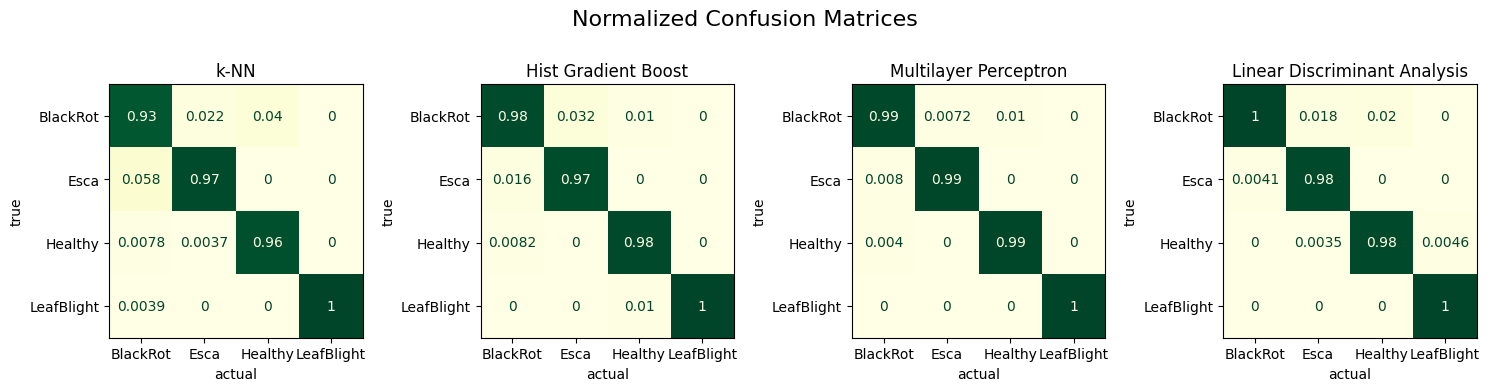

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

# predictions dictionary
predictions = {
    'k-NN': knn_pred,
    'Hist Gradient Boost': hgb_pred,
    'Multilayer Perceptron': mlp_pred,
    'Linear Discriminant Analysis': lda_pred,
    }

# create 1x4 subplot grid
fig, axes = plt.subplots(1, 4, figsize=(15, 4))

fig.suptitle('Normalized Confusion Matrices', fontsize=16)

# plot each confusion matrix
for ax, (model_name, y_pred) in zip(axes, predictions.items()):
  ConfusionMatrixDisplay.from_predictions(
      y_test,
      y_pred,
      display_labels=class_names,
      cmap='YlGn',
      colorbar=False,
      normalize='pred',
      ax=ax,
      )

  ax.set_title(model_name)
  ax.set_xlabel('actual')
  ax.set_ylabel('true')

plt.tight_layout()
plt.show()

Overall, all four classifiers performed very well on the grape leaf disease classification task, with strong diagonal values indicating high correct-classification rates across all classes.

General observations:
* The **LeafBlight** class was the easiest to classify, achieving a near-perfect recall (1.00) across all four models. None of the models showed meaningful confusion with other disease classes.
* **BlackRot** and **Esca** were the most frequently confused classes, particularly for k-NN. Approximately 5.8% of Esca samples were classified as BlackRot, while 2.2% of BlackRot samples were classified as Esca.
* The MLP exhibited the cleanest confusion matrix overall, with diagonal values close to 0.99 for all classes and minimal off-diagonal errors.
* The confusion matrices indicate that classification errors are concentrated among visually similar disease classes rather than between healthy and diseased leaves, suggesting that the extracted features capture the healthy-versus-diseased distinction effectively.

The consistently high diagonal values (over 0.93 for every class and model) indicate that the dataset is relatively well-structured and separable, allowing even simpler classifiers such as LDA to achieve strong performance.

#### 3.6. Multiclass ROC Curves

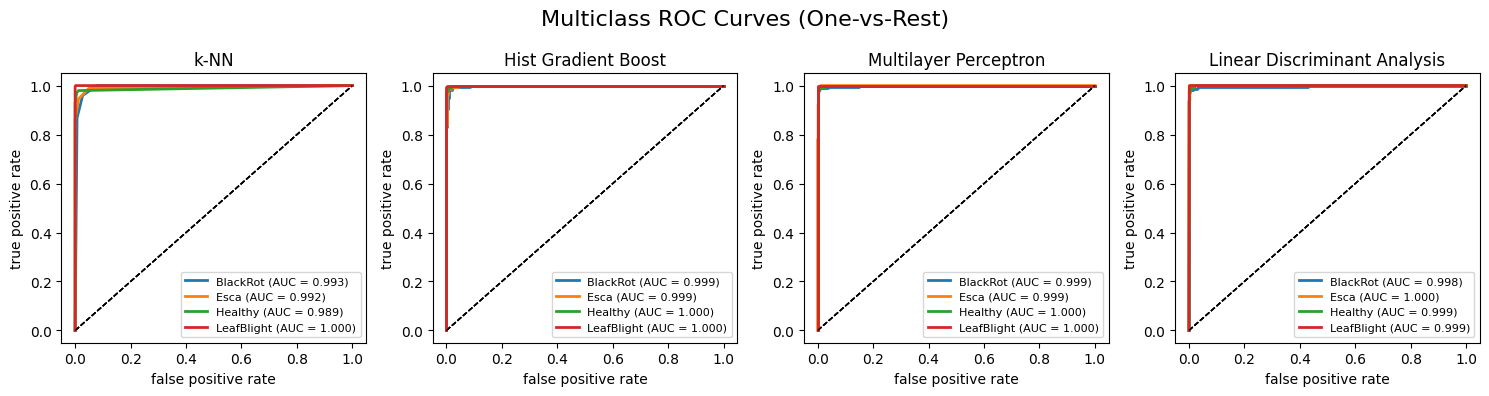

In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# binarize true labels
y_test_bin = label_binarize(y_test, classes=range(len(class_names)))

# probability predictions
probas = {
    'k-NN': knn.predict_proba(X_test),
    'Hist Gradient Boost': hgb.predict_proba(X_test),
    'Multilayer Perceptron': mlp.predict_proba(X_test),
    'Linear Discriminant Analysis': lda.predict_proba(X_test),
    }

# create 1 x 4 subplot grid
fig, axes = plt.subplots(1, 4, figsize=(15, 4))

fig.suptitle('Multiclass ROC Curves (One-vs-Rest)', fontsize=16)

# plot ROC for each classifier
for ax, (model_name, y_score) in zip(axes, probas.items()):

  # plot ROC curve for each class
  for i, cls in enumerate(class_names):

    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    ax.plot(
        fpr,
        tpr,
        lw=2,
        label=f'{cls} (AUC = {roc_auc:.3f})',
        )

    # random baseline
    ax.plot([0, 1], [0, 1], 'k--', lw=1)

    ax.set_title(model_name)
    ax.set_xlabel('false positive rate')
    ax.set_ylabel('true positive rate')
    ax.legend(loc='lower right', fontsize=8)

plt.tight_layout()
plt.show()

All models achieved near-perfect ROC performance, with AUC values ranging from approximately 0.989 to 1.000 across all classes. This indicates excellent embedding representation regardless of the classifier used.

Class-specific observations:
* The main source of classification error across models was confusion between **BlackRot** and **Esca**, while **LeafBlight** was almost perfectly identified in every experiment.
* **LeafBlight** consistently achieved an AUC of 1.0 for most models, confirming the observations from the confusion matrices that this class is the easiest to distinguish from the others.
* **Healthy** samples also demonstrated near-perfect separability, with AUC values ranging from 0.989 to 1.000. This suggests that the extracted features effectively capture the characteristics that differentiate healthy leaves from diseased ones.

The ROC analysis demonstrates that all evaluated classifiers possess excellent discriminative capability. The extracted image features provide a highly informative representation of grape leaf diseases and enable robust multiclass classification.

### 4. Conclusions

In this notebook, we presented a transfer learning approach for grape leaf disease classification using feature embeddings extracted from a pre-trained EfficientNetB0 model. These embeddings captured highly informative visual characteristics, enabling traditional machine learning classifiers to achieve excellent multiclass classification performance.

The results demonstrated consistently strong predictive performance across all evaluated models, with MLP and histogram-based gradient boosting achieving the highest ROC-AUC and F1 scores while producing the fewest misclassifications. This highlights the effectiveness of deep feature representations as an alternative to training end-to-end deep neural networks, offering reduced computational requirements, shorter training times, and a lower dependence on large annotated datasets.

Overall, the findings show that combining EfficientNetB0 embeddings with machine learning classifiers is an effective strategy for automated grape leaf disease recognition in precision agriculture. Furthermore, the strong performance of LDA suggests that the extracted features are largely linearly separable, whereas the additional gains achieved by MLP and histogram-based gradient boosting indicate the presence of more complex non-linear patterns within the data.